In [1]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

In [3]:
graph_builder = StateGraph(State)

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant"
)

In [5]:
def chatBot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatBot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()

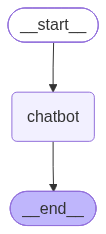

In [7]:
graph

In [8]:
response = graph.invoke({"messages":"who is the first person to walk on moon just the name"})
response

{'messages': [HumanMessage(content='who is the first person to walk on moon just the name', additional_kwargs={}, response_metadata={}, id='4cce5ab6-fe76-4fea-9d53-3c3015b1fbd2'),
  AIMessage(content='Neil Armstrong', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 3, 'prompt_tokens': 47, 'total_tokens': 50, 'completion_time': 0.004343193, 'completion_tokens_details': None, 'prompt_time': 0.002478003, 'prompt_tokens_details': None, 'queue_time': 0.050906616, 'total_time': 0.006821196}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fbf46-e002-7913-938c-e0a27e464f31-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 3, 'total_tokens': 50})]}

In [9]:
response['messages'][-1].content

'Neil Armstrong'

In [11]:
for event in graph.stream({"messages":"hi"}):
    print(event['chatbot'])

{'messages': [AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.005791687, 'completion_tokens_details': None, 'prompt_time': 0.002259615, 'prompt_tokens_details': None, 'queue_time': 0.053086735, 'total_time': 0.008051302}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fbf48-9012-7422-bab0-7536798b583d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}


In [13]:
event

{'chatbot': {'messages': [AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.005791687, 'completion_tokens_details': None, 'prompt_time': 0.002259615, 'prompt_tokens_details': None, 'queue_time': 0.053086735, 'total_time': 0.008051302}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fbf48-9012-7422-bab0-7536798b583d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}}

In [12]:
event['chatbot']['messages'][0].content

'How can I assist you today?'

## ChatBot With Tools

In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("winner of 2026 world cup football")

{'query': 'winner of 2026 world cup football',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_final',
   'title': '2026 FIFA World Cup final',
   'content': 'Kay, Oliver (July 20, 2026). "Spain are worthy World Cup winners. It\'s a victory for method over madness". The New York Times. ISSN "ISSN (identifier)") 0362-4331. Archived from the original on July 20, 2026. Retrieved July 20, 2026.\n      "Mondial-2026: la victoire de l\'Espagne sur l\'Argentine, \'le triomphe du football\'". TRT Français (in French). July 20, 2026. Retrieved July 20, 2026. [...] | Spanish captain Rodri lifts the World Cup trophy while celebrating with his teammates after the final. Spain lifting the FIFA World Cup Trophy |\n| Event | 2026 FIFA World Cup |\n| | Spain | Argentina |  --- | | | 1 | 0 | |\n| After extra time#Association_football "Overtime (sports)") |\n| Date | July 19, 2026 (2026-07-19) |\n| Venue | MetLife Stad

In [ ]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b

    Args:
        a (int): first number
        b (int): second number
    
    Returns:
        int: a*b
    """
    return a*b

In [16]:
tools = [tool, multiply]

llm_with_tools = llm.bind_tools(tools)

In [ ]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016677FECAD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016677FED550>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [22]:
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [18]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [19]:
def chatBot(state: State):
    return {"messages": llm_with_tools.invoke(state["messages"])}

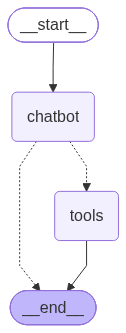

In [23]:
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatBot)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
graph_builder.add_edge("tools", END)

graph = graph_builder.compile()
graph

In [29]:
response = graph.invoke({"messages":"mutliply 5 and 2"})
response

{'messages': [HumanMessage(content='mutliply 5 and 2', additional_kwargs={}, response_metadata={}, id='6edec074-a0e7-4e7d-a302-207f9e95383f'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'st30814rj', 'function': {'arguments': '{"a":5,"b":2}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1753, 'total_tokens': 1772, 'completion_time': 0.034196956, 'completion_tokens_details': None, 'prompt_time': 0.117893871, 'prompt_tokens_details': None, 'queue_time': 0.051788509, 'total_time': 0.152090827}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fbf60-cce8-7503-94f7-ba55130d7ab9-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 2}, 'id': 'st30814rj', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1753, 'output_t

In [30]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

mutliply 5 and 2
================================== Ai Message ==================================
Tool Calls:
  multiply (st30814rj)
 Call ID: st30814rj
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [32]:
response = graph.invoke({"messages":"what is 5 multiplied by 2 and then multiply it by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 5 multiplied by 2 and then multiply it by 10
================================== Ai Message ==================================
Tool Calls:
  multiply (3zrr6d1ds)
 Call ID: 3zrr6d1ds
  Args:
    a: 5
    b: 2
  multiply (fef1jr09r)
 Call ID: fef1jr09r
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

100


In [33]:
response = graph.invoke({"messages":"give me recent ai news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (6btnz9q9e)
 Call ID: 6btnz9q9e
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (4vdjxs5s1)
 Call ID: 4vdjxs5s1
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://abcnews.com/video/135293631", "title": "Video Understanding Anthropic AI's recent hacks", "content": "### Iran escalation raises fears of broader regional conflict\n\nDeportation fears grow as Haitian temporary protected status ends\n\n### Deportation fears grow as Haitian temporary protected status ends\n\nTrump threatens to withdraw nomination for AG\n\n### Trump th